In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

In [42]:
## Semilla para reproducibilidad
np.random.seed(42)

## Tamaño de muestra
n = 200

## Parámetros verdaderos
beta_0_true = 3.14
beta_1_true = -5.54
sigma = 0.5

## Conjunto de datos simulado
x = np.random.uniform(size = n)
y = beta_0_true + beta_1_true * x +np.random.normal(loc = 0, scale = sigma * x, size = n)

In [43]:
X = np.column_stack((np.ones(n), x))

beta_hat = np.linalg.solve(X.T @ X, X.T @ y)

In [44]:
## Valores ajustados
y_hat = X @ beta_hat

## Residuos
residuals = y - y_hat

In [45]:
## Desviación estándar estimada
sigma_hat = np.sqrt((residuals**2).sum() / (n-len(beta_hat)))

## Residuos estandarizados
std_residuals = residuals/sigma_hat

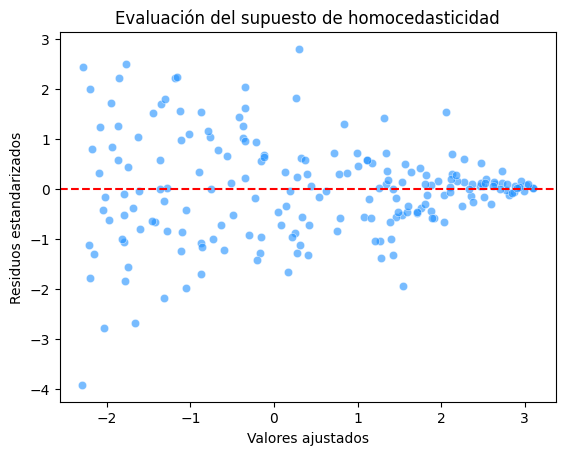

In [46]:
sns.scatterplot(x = y_hat, y = std_residuals, color = "dodgerblue", alpha = 0.6)
plt.axhline(0, linestyle = "--", color = "red")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos estandarizados")
plt.title("Evaluación del supuesto de homocedasticidad")
plt.show()

In [47]:
## Realizamos la prueba Breusch-Pagan
test = sms.het_breuschpagan(residuals, X) 

## Definimos los nombres del ouput
names = ["Lagrange multiplier statistic", "p-value",
         "f-value", "f p-value"]

## Imprimimos el resultado
lzip(names, test)

[('Lagrange multiplier statistic', np.float64(40.92806640297317)),
 ('p-value', np.float64(1.5793661940245205e-10)),
 ('f-value', np.float64(50.94397839104504)),
 ('f p-value', np.float64(1.7590906940893552e-11))]

In [48]:
## Definimos los pesos
weights = 1/x**2

## Construimos la matriz de pesos
W = np.diag(weights)

In [49]:
beta_hat_wls = np.linalg.solve(X.T @ W @ X, X.T @ W @ y)

In [50]:
## Valores ajustados de WLS
y_hat_wls = X @ beta_hat_wls

## Residuos de WLS
residuals_wls = y - y_hat_wls

In [51]:
std_residuals_wls = residuals_wls * np.sqrt(weights)

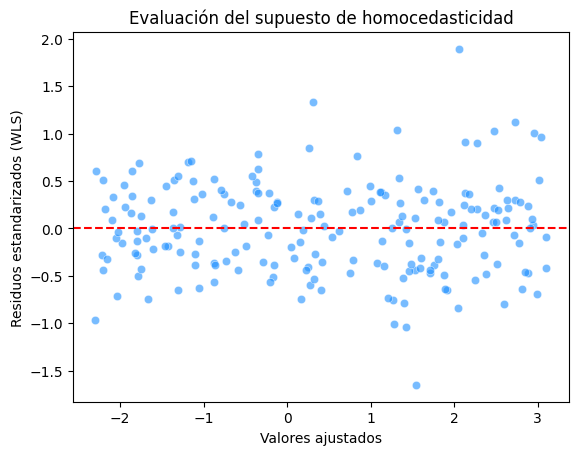

In [52]:
sns.scatterplot(x = y_hat, y = std_residuals_wls, color = "dodgerblue", alpha = 0.6)
plt.axhline(0, linestyle = "--", color = "red")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos estandarizados (WLS)")
plt.title("Evaluación del supuesto de homocedasticidad")
plt.show();

### Heteroscedasticity vs Homoscedasticity

When we talk about **homosedasticity** we are referring to a linear model where: 
1. There exists an error component such as: $\epsilon = \set{\epsilon_1, \epsilon_2, ..., \epsilon_n}^T$ where: $E(\epsilon) = 0$
2. $Var(\epsilon) = \sigma² I_n$

When we talk about **heteroscedasticity** we are referring to a linear model where:
1. here exists an error component such as: $\epsilon = \set{\epsilon_1, \epsilon_2, ..., \epsilon_n}^T$ where: $E(\epsilon) = 0$
2. $Var(\epsilon) = \sigma² \Omega$


### FGLS
Normally we would have an unknown matix $\Omega$ representing the covariance of a general linear model.
As in practice, the approach is to aproximate this matrix $\Omega$ by **the Feasable Generalized Least Squares (FGLS)**:

$$
\hat{\beta}_{FGLS} = (X^T \hat{\Omega}^{-1} X)^{-1} X^T \hat{\Omega}^{-1} y
$$

This process is done in two steps:
1. Estimate the model with an unefficient estimator such as *OLS*, using its resudies to build a concisistent estimator of the covariance matrix of errors. 
2. Implement *GLS* using that estimator of the covariance matrix of errors. 

\
We might also do for a heteroscedastoc regression:
1. Get the parameters estimators with *OLS*.
2. Get the associate residuals.
3. Make a regression for the square residuals, or any function of these againts predictors. 
4. Estimate $\sigma_i²(\sigma_i)$
5. Use *GLS* to estimate $\beta$ again.

### Code example:

In [53]:
## Realizamos la prueba Breusch-Pagan
test_wls = sms.het_breuschpagan(std_residuals_wls, X)

## Imprimimos el resultado
lzip(names, test_wls)

[('Lagrange multiplier statistic', np.float64(3.5930234679959705)),
 ('p-value', np.float64(0.058022588153936315)),
 ('f-value', np.float64(3.622165868162418)),
 ('f p-value', np.float64(0.05846528707267352))]

In [54]:
residuals_square = residuals**2
gamma_hat = np.linalg.solve(X.T @ X, X.T @ np.log(residuals_square))

In [55]:
var_model_fitted_values = X @ gamma_hat

In [56]:
## Definimos los pesos
weights_fgls = 1/np.exp(var_model_fitted_values)

## Construimos la matriz de pesos W
W = np.diag(weights_fgls)

In [57]:
beta_hat_fgls = np.linalg.solve(X.T @ W @ X, X.T @ W @ y)
beta_hat_fgls

array([ 3.14423619, -5.54349706])

In [58]:
## Encontramos los residuos
residuals_fgls = y - X @ beta_hat_fgls

## Encontramos los residuos estandarizados
std_residuals_fgls = residuals_fgls * np.sqrt(weights_fgls)

In [ ]:
## Realizamos la prueba Breusch-Pagan
test_fgls = sms.het_breuschpagan(std_residuals_fgls, X)

## Imprimimos el resultado
lzip(names, test_fgls)

[('Lagrange multiplier statistic', np.float64(1.5080956712790083)),
 ('p-value', np.float64(0.2194299001420042)),
 ('f-value', np.float64(1.5043582957354757)),
 ('f p-value', np.float64(0.22145854707866375))]